In [131]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import normaltest, skew, boxcox
import statsmodels.api as sm


# The background of the graphics has been made dark. 

In [132]:
sns.set_style('darkgrid')

# The Read to data and show the first 10 line. 

In [133]:
df = pd.read_csv(
    filepath_or_buffer='data/Country-data.csv'
)

df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


# The countries column has been deleted. 

In [134]:
df.drop(
    columns=['country'],
    axis=1,
    inplace=True
)

df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Was any empty data detected? 

In [135]:
df.isnull().sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
Gdpp          0
dtype: int64

# Check the data types 

In [136]:
df.dtypes.to_frame(name='dtype')

,dtype
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
Gdpp,int64


In [137]:
df.duplicated().sum()


np.int64(0)

In [138]:
df.nunique().sort_values()

life_expec    127
total_fer     138
child_mort    139
exports       147
health        147
imports       151
inflation     156
income        156
Gdpp          157
dtype: int64

In [139]:
df.shape

(167, 9)

# Make a heatmap and I looked correlation to Gdpp with between the diffrent columns

<function matplotlib.pyplot.show(close=None, block=None)>

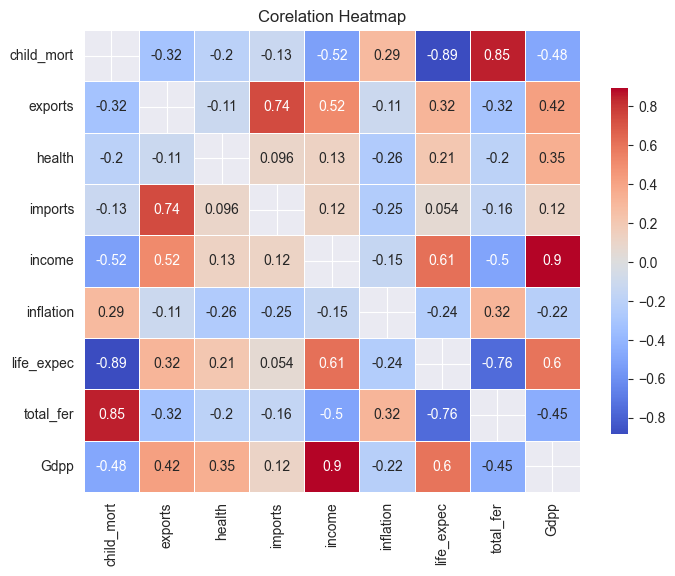

In [140]:
corr = df.corr()

np.fill_diagonal(corr.values, np.nan)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'shrink':0.75
    }
)
plt.title('Corelation Heatmap')
plt.show



# The relationship between income and gdpp was found to have the highest correlation. 

In [141]:
#VIF (Variance Inflation Factor)

X = df.drop(columns=['Gdpp'])
y = df['Gdpp']

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13


In [142]:
y[0:5]

0      553
1     4090
2     4460
3     3530
4    12200
Name: Gdpp, dtype: int64

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [144]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((133, 8), (34, 8), (133,), (34,))

In [145]:
#  Scaler to data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-0.83746628, -0.46960119,  1.02705834, ..., -0.59499747,
         1.1087671 , -0.70605991],
       [-0.29757844, -0.03846097, -0.99004398, ...,  0.67078917,
         0.68784703, -0.08237768],
       [-0.598059  ,  0.50257773, -0.31521816, ..., -0.63332824,
         0.34446486, -0.93109988],
       ...,
       [-0.83013748,  0.51103146, -0.4590335 , ...,  0.58367378,
         0.01215954, -0.98253759],
       [-0.71043384,  0.02071513,  0.08672728, ..., -0.55405324,
         0.41092593, -0.99539702],
       [-0.54431451, -0.00464606,  1.78669834, ...,  0.23521221,
        -0.06537837, -1.12399129]], shape=(133, 8))

# çoklu corelasyona bakıldı 
# ols = sıkıntıyı tespit edebilir model için hangi feature ları kullanmalıyım. modelin performansı ne (tahimn + istatistiksel datalar karar verede yardımcı)
# sklearn = tahmini söyler 

In [146]:
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

In [147]:
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   Gdpp   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     101.3
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.19e-50
Time:                        09:02:11   Log-Likelihood:                -1365.3
No. Observations:                 133   AIC:                             2749.
Df Residuals:                     124   BIC:                             2775.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.321e+04    624.340     21.154      0.0

In [148]:
# adjusted score

adj_r2 = 1- (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(
    f'adj r2: {adj_r2}'
)

adj r2: 0.77134950307774


In [149]:
y_pred = ols.predict(X_test_sm)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_absolute_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(
    f'Test R2: {r2:.4f}\n'
    f'Test RMSE: {rmse:.2f}\n'
    f'Test MAE: {mae:2f}'
)

Test R2: 0.8268
Test RMSE: 68.49
Test MAE: 4690.960179


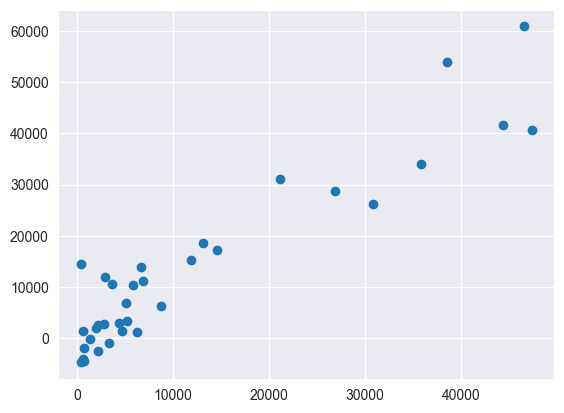

In [150]:
plt.scatter(y_test, y_pred)
plt.show()


In [151]:
residuals = y_test - y_pred

print(residuals)

101    -9013.007287
108     1840.940611
78     -6815.174675
56      -750.445889
98     -9964.976296
29      6675.090487
105       25.947509
82    -15424.695337
104    -7232.359614
109     4690.105886
19       -68.589577
42      4659.908715
15      2822.306932
67     -5437.195908
24     -4339.684909
31      5198.285025
132   -14105.337035
51     -2585.369380
160    -3368.807013
16      1315.458643
76      3230.880922
18      -438.180659
12      5208.642786
9      -4486.733508
133   -14291.689240
75      1682.586482
136     1426.012209
60     -1775.263223
55      2478.296458
147     2661.723594
30      4166.602518
141     5020.132908
120     4597.415845
148    -1694.799010
Name: Gdpp, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

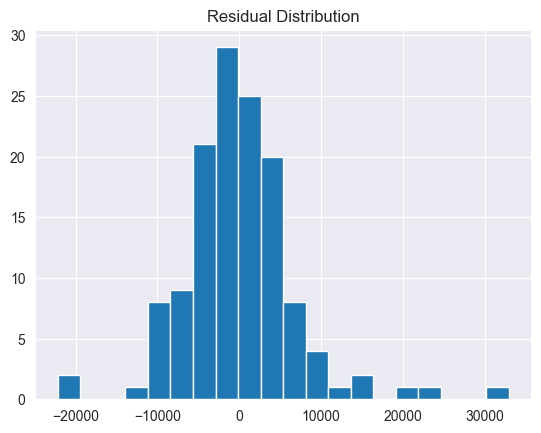

In [152]:
resid = y_train - ols.predict(X_train_sm)

plt.hist(resid, bins=20)
plt.title('Residual Distribution')
plt.show

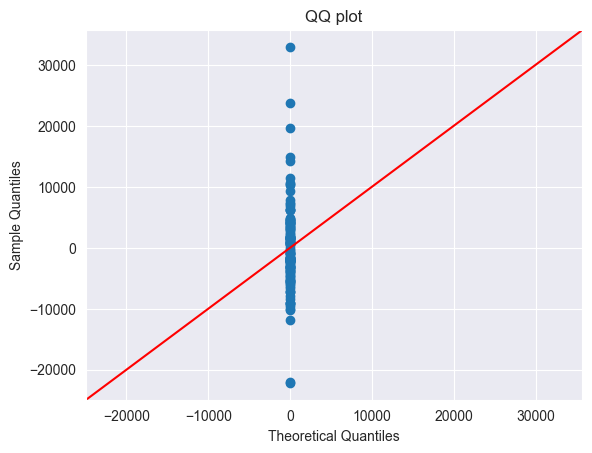

In [153]:
sm.qqplot(resid, line='45')
plt.title('QQ plot')
plt.show()

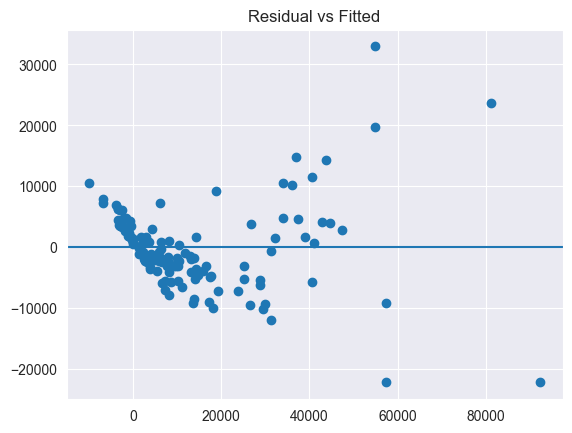

In [154]:
plt.scatter(ols.predict(X_train_sm), resid)

plt.axhline(0)
plt.title('Residual vs Fitted')
plt.show()

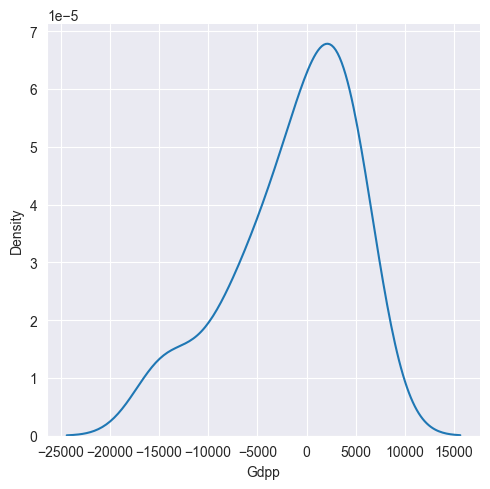

In [155]:
sns.displot(residuals, kind="kde")
plt.show()


In [156]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='euclidean',
    p=2
)

In [157]:
bp = het_breuschpagan(resid, X_train_sm)

print(
    f'LM p-value: {bp[1]}\n'
    f'f-value : {bp[3]}'
)

LM p-value: 1.6871001238117321e-10
f-value : 4.794144011492244e-14


In [158]:
ols_robust = ols.get_robustcov_results(cov_type='HC3')
print(ols_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   Gdpp   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     34.91
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.59e-28
Time:                        09:02:13   Log-Likelihood:                -1365.3
No. Observations:                 133   AIC:                             2749.
Df Residuals:                     124   BIC:                             2775.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.321e+04    712.104     18.547      0.0

In [159]:
# Regularization 
# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test_scaled)

print(
    f'RIDGE\n'
    f'R2: {r2_score(y_test, y_pred)}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, ridge_pred))}\n'
    F'MAE: {mean_absolute_error(y_test, ridge_pred)}'
)

RIDGE
R2: 0.8267799265740454
RMSE: 63561.3029104327
MAE: 61927.60980489149


c:\Users\Merve\MachineLearning\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [160]:
# LOSSO 
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

print(
    f' LOSSO\n'
    f'R2: {r2_score(y_test, lasso_pred)}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, lasso_pred))}\n'
    f'MAE: {mean_absolute_error(y_test, lasso_pred)}'
)


 LOSSO
R2: 0.8267909119442662
RMSE: 6091.0281018091155
MAE: 4690.777513595381


In [161]:
# ElasticNet
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_scaled,  y_train)
elastic_pred = elastic.predict(X_test_scaled)

print(
    f'ELASTIC\n'
    f'R2: {r2_score(y_test, elastic_pred)}\n'
    f'RMSE: {np.sqrt(mean_squared_error(y_test, elastic_pred))}\n'
    f'MAE: {mean_absolute_error(y_test, elastic_pred)}'
    )


ELASTIC
R2: 0.841335206432158
RMSE: 5829.691205695283
MAE: 4578.842374149511


In [162]:
coef_df = pd.DataFrame({
    'feature' : X.columns,
    'ridge' : ridge.coef_,
    'lasso' : lasso.coef_,
    'elastic' : elastic.coef_
})
coef_df

,feature,ridge,lasso,elastic
0,child_mort,89.192645,3643.788773,2360.142058
1,exports,58.435225,1386.366069,1968.933079
2,health,1718.692083,4667.196945,4600.356261
3,imports,-16.292005,-340.757431,-722.015253
4,income,0.788773,15344.347110,14150.142847
5,inflation,-80.294366,-921.407969,-937.191772
6,life_expec,450.903767,4069.723331,3353.189216
7,total_fer,514.462397,809.623644,860.194314


In [163]:
X.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13
